<a href="https://colab.research.google.com/github/youssef1061/XAI-project/blob/main/EDA_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **IMPORTS**

In [1]:
import os
import zipfile
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import (
    mutual_info_classif, chi2, f_classif,
    SelectKBest, VarianceThreshold, RFE,
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor

# **DATA PREPROCESSING**

 **loading data from drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/LLCP2015XPT.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction done")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extraction done


In [3]:
xpt_path = "/content/LLCP2015.XPT "
data = pd.read_sas(xpt_path, format="xport")
print(f"Raw data loaded — shape: {data.shape}")

Rows, Cols = data.shape
print("Rows =", Rows)
print("Columns =", Cols)


Raw data loaded — shape: (441456, 330)
Rows = 441456
Columns = 330


**Basic Inspection of Raw Data**

In [4]:
data.head()

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENUM,...,_PAREC1,_PASTAE1,_LMTACT1,_LMTWRK1,_LMTSCL1,_RFSEAT2,_RFSEAT3,_FLSHOT6,_PNEUMO2,_AIDTST3
0,1.0,1.0,b'01292015',b'01',b'29',b'2015',1200.0,2.015000e+09,2.015000e+09,1.0,...,4.0,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0
1,1.0,1.0,b'01202015',b'01',b'20',b'2015',1100.0,2.015000e+09,2.015000e+09,1.0,...,2.0,2.0,3.0,3.0,4.0,2.0,2.0,NaN,NaN,2.0
2,1.0,1.0,b'02012015',b'02',b'01',b'2015',1200.0,2.015000e+09,2.015000e+09,1.0,...,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,NaN
3,1.0,1.0,b'01142015',b'01',b'14',b'2015',1100.0,2.015000e+09,2.015000e+09,1.0,...,4.0,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,9.0
4,1.0,1.0,b'01142015',b'01',b'14',b'2015',1100.0,2.015000e+09,2.015000e+09,1.0,...,4.0,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0


In [5]:
data.info(verbose=False, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 441456 entries, 0 to 441455
Columns: 330 entries, _STATE to _AIDTST3
dtypes: float64(323), object(7)
memory usage: 1.1+ GB


In [6]:
data.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
_STATE,441456.0,2.997000e+01,16.03,1.000000e+00,1.900000e+01,2.900000e+01,4.400000e+01,7.200000e+01
FMONTH,441456.0,6.360000e+00,3.49,1.000000e+00,3.000000e+00,6.000000e+00,9.000000e+00,1.200000e+01
DISPCODE,441456.0,1.115040e+03,35.75,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.200000e+03
SEQNO,441456.0,2.015005e+09,4113.44,2.015000e+09,2.015002e+09,2.015004e+09,2.015007e+09,2.015023e+09
_PSU,441456.0,2.015005e+09,4113.44,2.015000e+09,2.015002e+09,2.015004e+09,2.015007e+09,2.015023e+09
...,...,...,...,...,...,...,...,...
_RFSEAT2,441456.0,1.820000e+00,2.36,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,9.000000e+00
_RFSEAT3,441456.0,1.890000e+00,2.35,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,9.000000e+00
_FLSHOT6,157954.0,2.290000e+00,2.52,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,9.000000e+00
_PNEUMO2,157954.0,2.410000e+00,2.78,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,9.000000e+00


**Selecting Raw BRFSS Columns**

In [7]:
RAW_COL_MAP = {
    "DIABETE3" : "Diabetes",
    "_RFHYPE5"  : "HighBP",
    "TOLDHI2"   : "HighChol",
    "_BMI5"     : "BMI",
    "SMOKE100"  : "Smoker",
    "CVDSTRK3"  : "Stroke",
    "_MICHD"    : "HeartDiseaseorAttack",
    "_TOTINDA"  : "PhysActivity",
    "_FRTLT1"   : "Fruits",
    "_VEGLT1"   : "Veggies",
    "_RFDRHV5"  : "HvyAlcoholConsump",
    "HLTHPLN1"  : "AnyHealthcare",
    "MEDCOST"   : "NoDocbcCost",
    "GENHLTH"   : "GenHlth",
    "MENTHLTH"  : "MentHlth",
    "PHYSHLTH"  : "PhysHlth",
    "DIFFWALK"  : "DiffWalk",
    "SEX"       : "Sex",
    "_AGEG5YR"  : "Age",
    "EDUCA"     : "Education",
    "INCOME2"   : "Income",
    "_RACE"     : "Race",
    "MARITAL"   : "MaritalStatus",
    "CHECKUP1"  : "TimeSinceCheckup",
}
available = {k: v for k, v in RAW_COL_MAP.items() if k in data.columns}
df = data[list(available.keys())].copy().rename(columns=available)
print(f"Columns selected: {df.shape[1]} | Rows: {df.shape[0]}")
print(df.columns.tolist())


Columns selected: 24 | Rows: 441456
['Diabetes', 'HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'Race', 'MaritalStatus', 'TimeSinceCheckup']


In [8]:
df.describe()

,Diabetes,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Race,MaritalStatus,TimeSinceCheckup
count,441449.000000,441456.000000,382302.000000,405058.000000,427201.000000,441456.000000,437514.000000,441456.000000,441456.000000,441456.000000,...,441456.000000,441455.000000,429122.000000,441456.000000,441456.000000,441456.000000,438155.000000,441456.000000,441456.000000,441455.000000
mean,2.757888,1.428410,1.630876,2804.242400,1.613987,1.973880,1.911699,1.931871,2.131746,2.109316,...,64.679178,60.655113,1.856600,1.576542,7.803623,4.920094,20.253013,2.021758,2.263653,1.574185
std,0.723319,0.646749,0.740235,665.463433,0.746530,0.348689,0.283733,2.209728,2.322882,2.522517,...,35.843085,37.055684,0.579838,0.494107,3.495609,1.076198,31.853507,2.273676,1.687844,1.249199
min,1.000000,1.000000,1.000000,1202.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,1.000000,1.000000,2373.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,...,28.000000,15.000000,2.000000,1.000000,5.000000,4.000000,5.000000,1.000000,1.000000,1.000000
50%,3.000000,1.000000,2.000000,2695.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,...,88.000000,88.000000,2.000000,2.000000,8.000000,5.000000,7.000000,1.000000,1.000000,1.000000
75%,3.000000,2.000000,2.000000,3090.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,88.000000,88.000000,2.000000,2.000000,10.000000,6.000000,8.000000,1.000000,3.000000,2.000000
max,9.000000,9.000000,9.000000,9995.000000,9.000000,9.000000,2.000000,9.000000,9.000000,9.000000,...,99.000000,99.000000,9.000000,2.000000,14.000000,9.000000,99.000000,9.000000,9.000000,9.000000


In [9]:
#checking for Dtype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 441456 entries, 0 to 441455
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes              441449 non-null  float64
 1   HighBP                441456 non-null  float64
 2   HighChol              382302 non-null  float64
 3   BMI                   405058 non-null  float64
 4   Smoker                427201 non-null  float64
 5   Stroke                441456 non-null  float64
 6   HeartDiseaseorAttack  437514 non-null  float64
 7   PhysActivity          441456 non-null  float64
 8   Fruits                441456 non-null  float64
 9   Veggies               441456 non-null  float64
 10  HvyAlcoholConsump     441456 non-null  float64
 11  AnyHealthcare         441456 non-null  float64
 12  NoDocbcCost           441455 non-null  float64
 13  GenHlth               441454 non-null  float64
 14  MentHlth              441456 non-null  float64
 15  

In [10]:
df.isnull().sum()

,0
Diabetes,7
HighBP,0
HighChol,59154
BMI,36398
Smoker,14255
Stroke,0
HeartDiseaseorAttack,3942
PhysActivity,0
Fruits,0
Veggies,0


###  Drop BRFSS Sentinel Codes (Don't Know / Refused / Missing) + dropna()

CDC BRFSS Codebook defines 7, 9, 77, 88, 99, 14 as non-responses.

In [11]:
print("Shape before removing 7 and 9 / drop null:", df.shape)

for c in ["MentHlth", "PhysHlth"]:
    if c in df.columns:
        df[c] = df[c].replace({88: 0})
        df = df[~df[c].isin([77, 99])]


cols_with_7_9 = [
    "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
    "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump",
    "AnyHealthcare", "NoDocbcCost", "GenHlth", "DiffWalk",
    "Education", "MaritalStatus", "TimeSinceCheckup",
]
for c in cols_with_7_9:
    if c in df.columns:
        df = df[~df[c].isin([7, 9])]

if "Income" in df.columns:
    df = df[~df["Income"].isin([77, 99])]
if "Age" in df.columns:
    df = df[df["Age"] != 14]
if "Sleep" in df.columns:
    df = df[~df["Sleep"].isin([77, 99])]

df = df.dropna()
print(f"Shape after removing 7 and 9 / NaN drop: {df.shape}")



Shape before removing 7 and 9 / drop null: (441456, 24)
Shape after removing 7 and 9 / NaN drop: (253867, 24)


In [12]:
df["BMI"] = (df["BMI"] / 100).round(1)

binary_recode = {
    "HighBP":              {1: 1, 2: 0},
    "HighChol":            {1: 1, 2: 0},
    "Smoker":              {1: 1, 2: 0},
    "Stroke":              {1: 1, 2: 0},
    "HeartDiseaseorAttack":{1: 1, 2: 0},
    "PhysActivity":        {1: 1, 2: 0},
    "Fruits":              {1: 1, 2: 0},
    "Veggies":             {1: 1, 2: 0},
    "HvyAlcoholConsump":   {1: 1, 2: 0},
    "AnyHealthcare":       {1: 1, 2: 0},
    "NoDocbcCost":         {1: 1, 2: 0},
    "DiffWalk":            {1: 1, 2: 0},
    "Sex":                 {1: 1, 2: 0},
}
for col, mapping in binary_recode.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)

target_map = {1: 2, 3: 0, 4: 1, 2: 1}
df["Diabetes"] = df["Diabetes"].map(target_map)
df = df.dropna(subset=["Diabetes"])
df["Diabetes"] = df["Diabetes"].astype(int)

df["Age"]      = df["Age"].astype(int)
df["Education"]= df["Education"].astype(int)
df["Income"]   = df["Income"].astype(int)
df["GenHlth"]  = df["GenHlth"].astype(int)

df = df.dropna()
print(f"Shape after recoding: {df.shape}")
df.dtypes


Shape after recoding: (253698, 24)


,0
Diabetes,int64
HighBP,int64
HighChol,int64
BMI,float64
Smoker,int64
Stroke,int64
HeartDiseaseorAttack,int64
PhysActivity,int64
Fruits,int64
Veggies,int64


In [13]:
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing": missing, "pct": pct})
print(missing_df[missing_df["missing"] > 0])
print(f"\nTotal NaN cells: {df.isnull().sum().sum()}")

Empty DataFrame
Columns: [missing, pct]
Index: []

Total NaN cells: 0


In [14]:
print(f"Duplicate rows before drop: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after duplicate removal: {df.shape}")


Duplicate rows before drop: 3629
Shape after duplicate removal: (250069, 24)


In [15]:
df.to_csv("brfss2015_clean.csv", index=False)
print(f"Saved brfss2015_clean.csv | Shape: {df.shape}")
df_clean = df.copy()


Saved brfss2015_clean.csv | Shape: (250069, 24)


In [16]:
print(f"Final preprocessed shape: {df_clean.shape}")
print("Columns:", list(df_clean.columns))
print("\nTarget distribution (Diabetes):")
print(df_clean["Diabetes"].value_counts().sort_index())
print(df_clean["Diabetes"].value_counts(normalize=True).sort_index().round(4))
print("\nMissing values:", df_clean.isnull().sum().sum())

Final preprocessed shape: (250069, 24)
Columns: ['Diabetes', 'HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'Race', 'MaritalStatus', 'TimeSinceCheckup']

Target distribution (Diabetes):
Diabetes
0    208204
1      6594
2     35271
Name: count, dtype: int64
Diabetes
0    0.8326
1    0.0264
2    0.1410
Name: proportion, dtype: float64

Missing values: 0


# PART 2 — EXPLORATORY DATA ANALYSIS (EDA)


### Class Distribution of Target

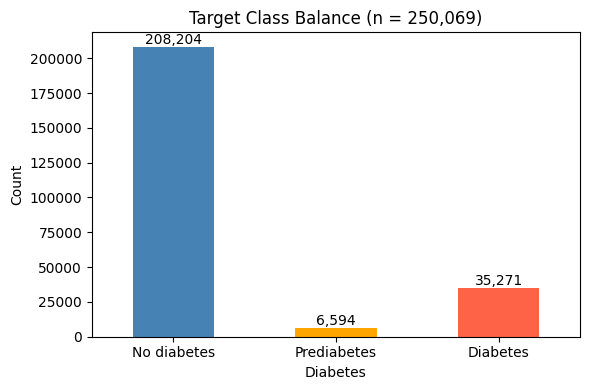

In [18]:
# TARGET CLASS BALANCE

plt.figure(figsize=(6, 4))
counts = df_clean["Diabetes"].value_counts().sort_index()
counts.plot(kind="bar", color=["steelblue", "orange", "tomato"])
plt.xticks([0, 1, 2], ["No diabetes", "Prediabetes", "Diabetes"], rotation=0)
plt.title(f"Target Class Balance (n = {len(df_clean):,})")
plt.ylabel("Count")
for i, v in enumerate(counts.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


### Distributions of Continuous Features

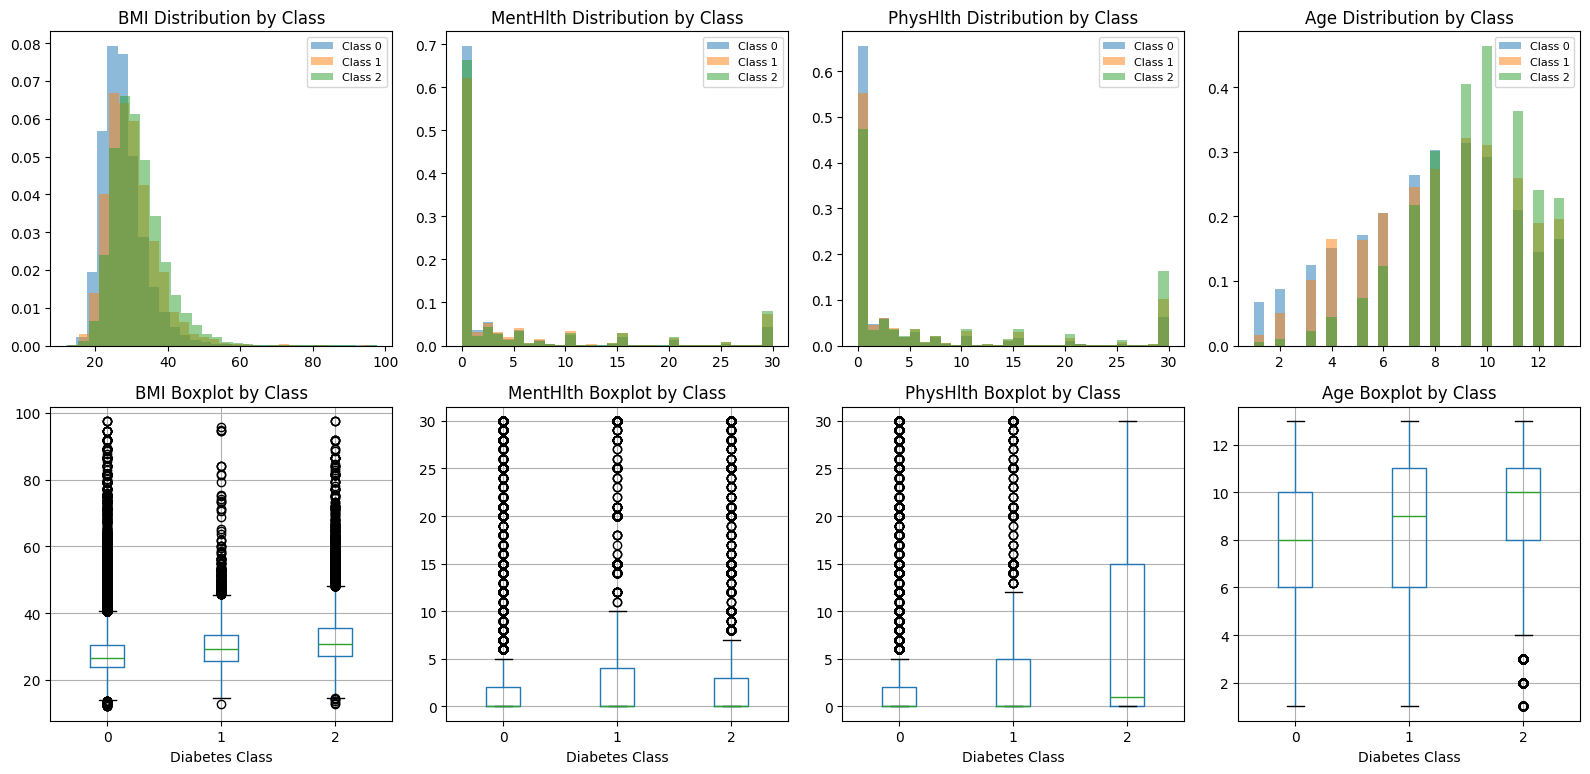

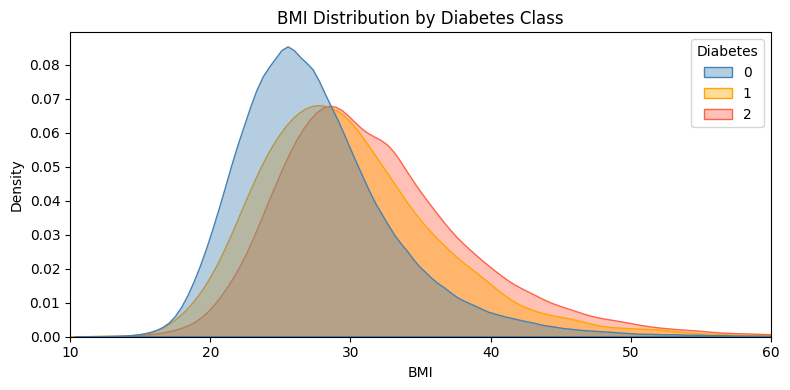

In [20]:
continuous_cols = ["BMI", "MentHlth", "PhysHlth", "Age"]
fig, axes = plt.subplots(2, len(continuous_cols), figsize=(16, 8))
for i, col in enumerate(continuous_cols):
    for cls, grp in df_clean.groupby("Diabetes"):
        axes[0, i].hist(grp[col], bins=30, alpha=0.5, label=f"Class {int(cls)}", density=True)
    axes[0, i].set_title(f"{col} Distribution by Class")
    axes[0, i].legend(fontsize=8)
    df_clean.boxplot(column=col, by="Diabetes", ax=axes[1, i])
    axes[1, i].set_title(f"{col} Boxplot by Class")
    axes[1, i].set_xlabel("Diabetes Class")
plt.suptitle("")
plt.tight_layout(); plt.savefig("continuous_distributions.png", dpi=150); plt.show()

# BMI split by diabetes status
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df_clean, x="BMI", hue="Diabetes",
            common_norm=False, fill=True, alpha=.4,
            palette={0: "steelblue", 1: "orange", 2: "tomato"})
plt.xlim(10, 60)
plt.title("BMI Distribution by Diabetes Class")
plt.tight_layout()
plt.show()


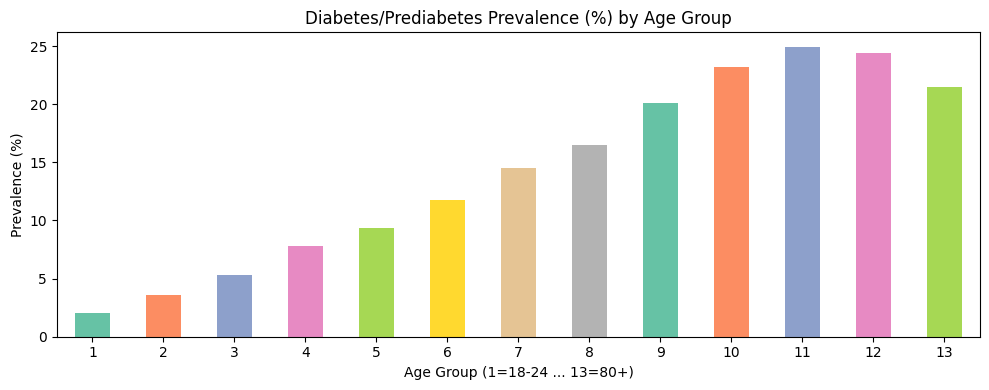

→ Risk increases clearly with age, confirming Age as key predictor.


In [22]:
age_diab = df_clean.copy()
age_diab["HasDiabetes"] = (age_diab["Diabetes"] > 0).astype(int)
age_rate = age_diab.groupby("Age")["HasDiabetes"].mean() * 100

plt.figure(figsize=(10, 4))
age_rate.plot(kind="bar", color=sns.color_palette("Set2", len(age_rate)))
plt.title("Diabetes/Prediabetes Prevalence (%) by Age Group")
plt.xlabel("Age Group (1=18-24 ... 13=80+)")
plt.ylabel("Prevalence (%)")
plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig("age_prevalence.png", dpi=150); plt.show()
print("→ Risk increases clearly with age, confirming Age as key predictor.")


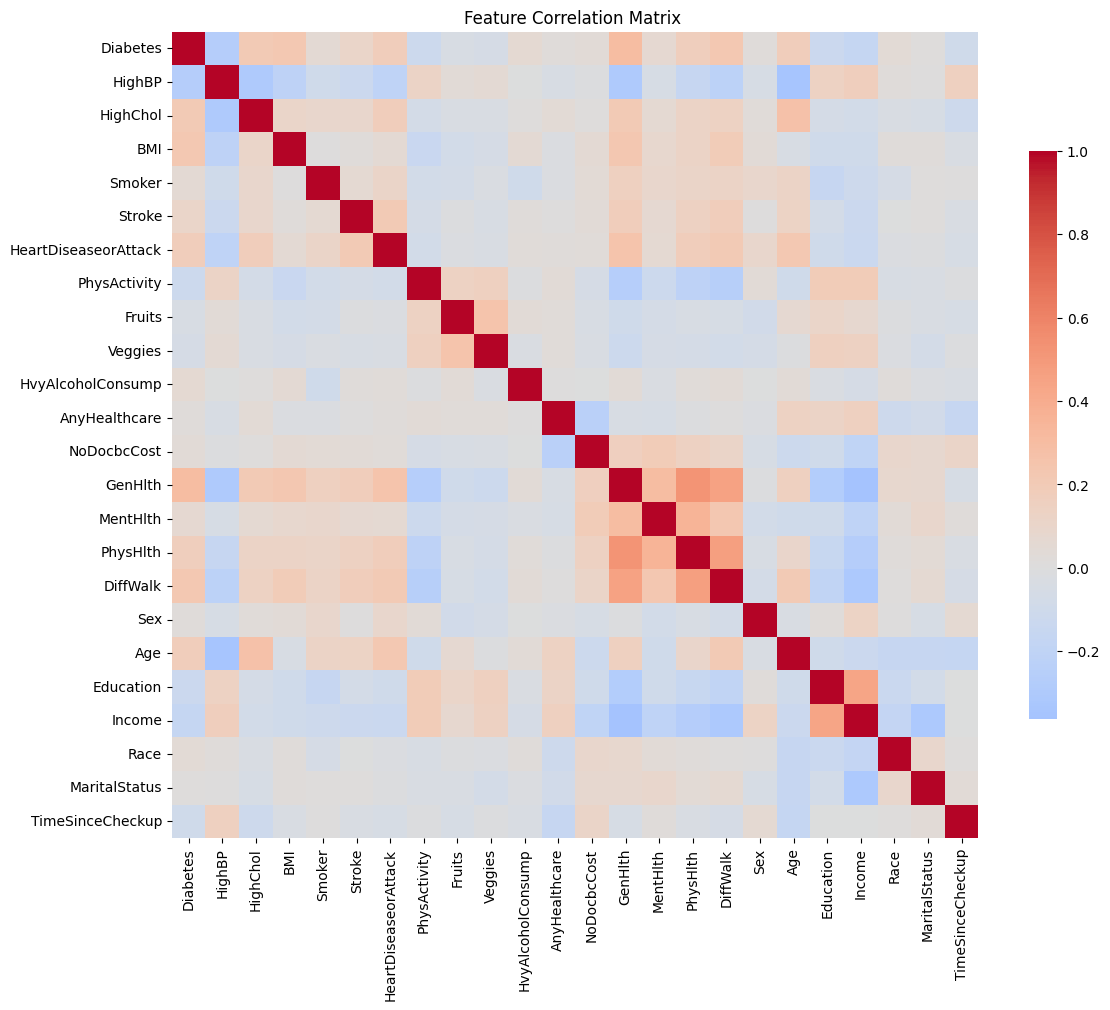

Top 15 features correlated with Diabetes


,Diabetes
GenHlth,0.297434
HighBP,0.266663
BMI,0.222868
DiffWalk,0.220050
HighChol,0.205771
Age,0.178396
HeartDiseaseorAttack,0.175963
PhysHlth,0.172262
Income,0.166145
Education,0.124698


In [23]:
# CORRELATION HEATMAP + TARGET CORRELATIONS

plt.figure(figsize=(12, 10))
corr = df_clean.corr(numeric_only=True)
# mask = np.triu(np.ones_like(corr, dtype=bool)) use this line and add mask=mask in sns.heatmap for cleaner heatmap
sns.heatmap(corr,  cmap="coolwarm", center=0,
            annot=False, square=True, cbar_kws={"shrink": .7})
plt.title("Feature Correlation Matrix ")
plt.tight_layout()
plt.show()

tgt_corr = (corr["Diabetes"].drop("Diabetes")
            .abs().sort_values(ascending=False))
print("Top 15 features correlated with Diabetes")
display(tgt_corr.head(15))


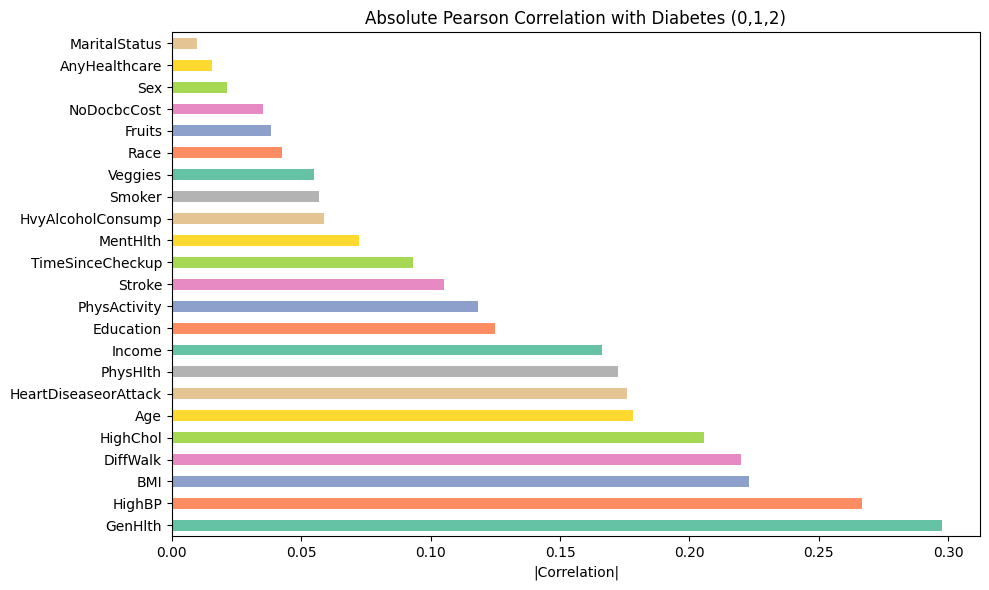

GenHlth                 0.297434
HighBP                  0.266663
BMI                     0.222868
DiffWalk                0.220050
HighChol                0.205771
Age                     0.178396
HeartDiseaseorAttack    0.175963
PhysHlth                0.172262
Income                  0.166145
Education               0.124698
Name: Diabetes, dtype: float64


In [25]:
target_corr = corr["Diabetes"].drop("Diabetes").abs().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
target_corr.plot(kind="barh", color=sns.color_palette("Set2", len(target_corr)))
plt.title("Absolute Pearson Correlation with Diabetes (0,1,2)")
plt.xlabel("Correlation"); plt.tight_layout()
plt.savefig("target_correlation.png", dpi=150); plt.show()
print(target_corr.head(10))


In [26]:
for col in ["BMI", "MentHlth", "PhysHlth"]:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    pct_out = n_out / len(df_clean) * 100
    print(f"{col}: {n_out} outliers ({pct_out:.2f}%)  [lower={lower:.1f}, upper={upper:.1f}]")


BMI: 8927 outliers (3.57%)  [lower=13.5, upper=42.0]
MentHlth: 36161 outliers (14.46%)  [lower=-3.0, upper=5.0]
PhysHlth: 40884 outliers (16.35%)  [lower=-4.5, upper=7.5]


In [28]:
for col in ["BMI", "MentHlth", "PhysHlth"]:
    M = df_clean[col].mean()
    STD = df_clean[col].std()
    lower, upper = M - 3*STD, M + 3*STD
    mask = (df_clean[col] < lower) | (df_clean[col] > upper)
    n_out = mask.sum()
    pct_out = n_out / len(df_clean) * 100
    print(f"{col}: {n_out} outliers ({pct_out:.2f}%) [lower={lower:.1f}, upper={upper:.1f}]")

BMI: 3060 outliers (1.22%) [lower=8.6, upper=48.3]
MentHlth: 12667 outliers (5.07%) [lower=-19.1, upper=25.6]
PhysHlth: 0 outliers (0.00%) [lower=-22.0, upper=30.6]


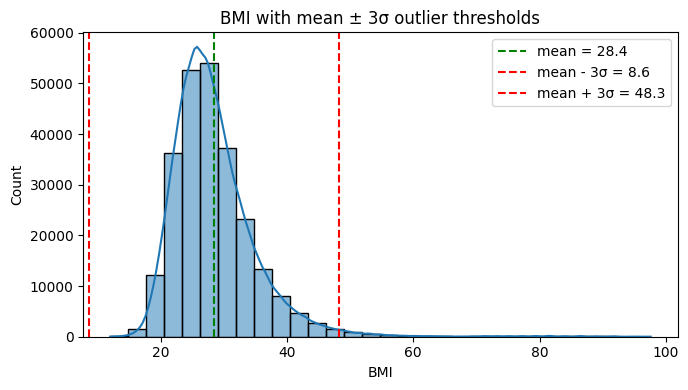

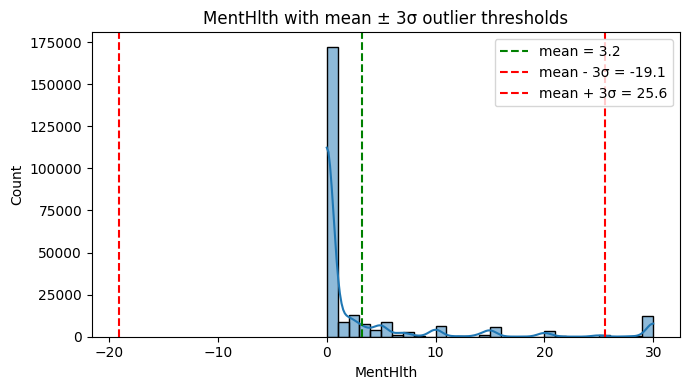

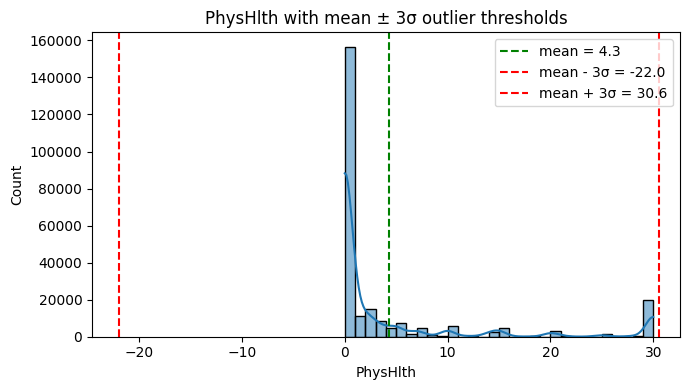

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in ["BMI", "MentHlth", "PhysHlth"]:
    mu = df_clean[col].mean()
    sigma = df_clean[col].std()
    lower, upper = mu - 3*sigma, mu + 3*sigma

    plt.figure(figsize=(7, 4))
    sns.histplot(df_clean[col], bins=30, kde=True)
    plt.axvline(mu, color="green", linestyle="--", label=f"mean = {mu:.1f}")
    plt.axvline(lower, color="red", linestyle="--", label=f"mean - 3σ = {lower:.1f}")
    plt.axvline(upper, color="red", linestyle="--", label=f"mean + 3σ = {upper:.1f}")
    plt.title(f"{col} with mean ± 3σ outlier thresholds")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

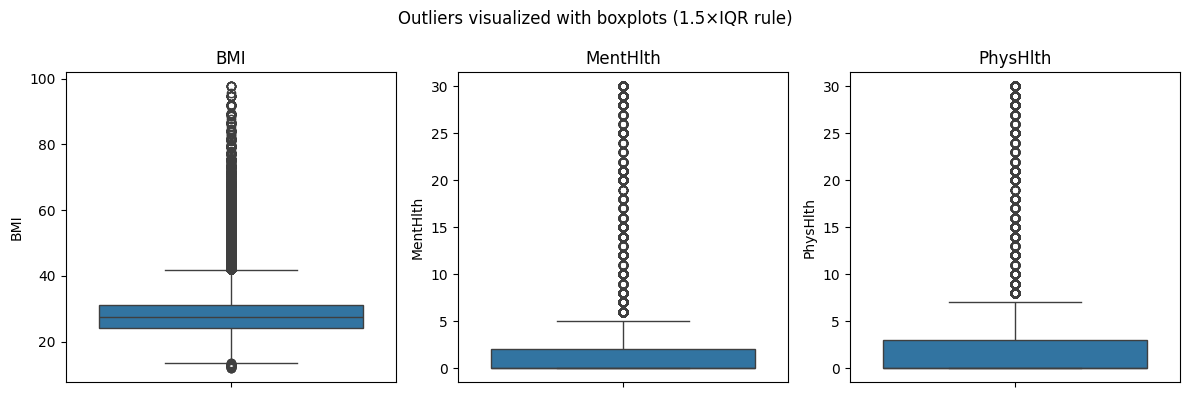

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

for ax, col in zip(axes, ["BMI", "MentHlth", "PhysHlth"]):
    sns.boxplot(y=df_clean[col], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

fig.suptitle("Outliers visualized with boxplots (1.5×IQR rule)")
plt.tight_layout()
plt.show()

# FEATURE ENGINEERING & FEATURE SELECTION


In [31]:
df_fe = df_clean.copy()

df_fe["BMI_class"] = pd.cut(
    df_fe["BMI"],
    bins=[0, 18.5, 25, 30, 35, 40, np.inf],
    labels=[0, 1, 2, 3, 4, 5],
).astype(int)

findrisc = np.zeros(len(df_fe))
a = df_fe["Age"]
findrisc += np.where(a >= 10, 4, np.where(a >= 7, 3, np.where(a >= 5, 2, 0)))
b = df_fe["BMI"]
findrisc += np.where(b >= 30, 3, np.where(b >= 25, 1, 0))
findrisc += np.where(df_fe["PhysActivity"] == 0, 2, 0)
findrisc += np.where((df_fe["Fruits"] == 0) & (df_fe["Veggies"] == 0), 1, 0)
findrisc += np.where(df_fe["HighBP"] == 1, 2, 0)
df_fe["FINDRISC_score"] = findrisc

df_fe["MetS_score"] = (
    1.0 / (1.0 + np.exp(-0.5 * (df_fe["BMI"] - 30)))
    + df_fe["HighBP"]
    + df_fe["HighChol"]
)

df_fe["CV_burden_weighted"] = (
    2.0 * df_fe["HeartDiseaseorAttack"]
    + 2.0 * df_fe["Stroke"]
    + 1.0 * df_fe["DiffWalk"]
)

df_fe["UnhealthyDays_total"] = df_fe["MentHlth"] + df_fe["PhysHlth"]

df_fe["Healthcare_engagement"] = (
    df_fe["AnyHealthcare"]
    + (1 - df_fe["NoDocbcCost"])
    + (4 - df_fe["TimeSinceCheckup"]) / 4.0
)

df_fe["Protective_lifestyle"] = (
    2.0 * df_fe["PhysActivity"]
    + 2.0 * (1 - df_fe["Smoker"])
    + df_fe["Fruits"]
    + df_fe["Veggies"]
    + (1 - df_fe["HvyAlcoholConsump"])
)

df_fe["SES_risk_score"] = (
    (8 - df_fe["Income"])
    + (6 - df_fe["Education"])
    + 2.0 * (1 - df_fe["AnyHealthcare"])
    + 2.0 * df_fe["NoDocbcCost"]
)

df_fe["BMI_x_Age"] = df_fe["BMI"] * df_fe["Age"]
df_fe["GenHlth_x_DiffWalk"] = df_fe["GenHlth"] * df_fe["DiffWalk"]

print(f"Shape after feature engineering: {df_fe.shape}")
print(f"Added {df_fe.shape[1] - df_clean.shape[1]} engineered features.")
df_fe.head(3)


Shape after feature engineering: (250069, 34)
Added 10 engineered features.


,Diabetes,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,BMI_class,FINDRISC_score,MetS_score,CV_burden_weighted,UnhealthyDays_total,Healthcare_engagement,Protective_lifestyle,SES_risk_score,BMI_x_Age,GenHlth_x_DiffWalk
0,0,0,1,40.2,1,0,0,0,0,1,...,5,8.0,1.993940,1.0,33.0,2.75,1.0,7.0,361.8,5
1,0,1,0,25.1,1,0,0,1,0,0,...,2,7.0,1.079439,0.0,0.0,0.00,2.0,11.0,175.7,0
3,0,0,1,28.2,0,0,0,0,1,0,...,2,6.0,1.289050,1.0,60.0,1.75,3.0,4.0,253.8,5


In [32]:
# TRAIN / TEST SPLIT  +  SCALING

RANDOM_STATE = 42
y = df_fe["Diabetes"].astype(int)
X = df_fe.drop(columns=["Diabetes"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE,
)
print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print("Train target balance:")
print(y_train.value_counts(normalize=True).sort_index().round(4))

# Scale continuous columns originals + engineered continuous set
scale_cols = [c for c in [
    "BMI", "MentHlth", "PhysHlth",
    "FINDRISC_score", "MetS_score", "CV_burden_weighted",
    "UnhealthyDays_total", "Healthcare_engagement",
    "Protective_lifestyle", "SES_risk_score",
    "BMI_x_Age", "GenHlth_x_DiffWalk"
] if c in X_train.columns]
scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])


Train: (200055, 33)   Test: (50014, 33)
Train target balance:
Diabetes
0    0.8326
1    0.0264
2    0.1410
Name: proportion, dtype: float64


## FEATURE SELECTION  (multi-method + consensus ranking)

### **Low-variance filter + VIF (multicollinearity diagnostic)**

In [33]:

vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train)
low_var_cols = X_train.columns[~vt.get_support()].tolist()
print(f"Low-variance columns dropped: {low_var_cols}")
X_train_fs = X_train.drop(columns=low_var_cols)
X_test_fs  = X_test.drop(columns=low_var_cols)

def vif_table(frame):
    return (pd.DataFrame({
        "feature": frame.columns,
        "VIF": [variance_inflation_factor(frame.values, i)
                for i in range(frame.shape[1])],
    }).sort_values("VIF", ascending=False))

vif_df = vif_table(X_train_fs.fillna(0))
print("\nTop-10 VIF scores:")
display(vif_df.head(10))


Low-variance columns dropped: []


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



Top-10 VIF scores:


,feature,VIF
4,Stroke,inf
29,Protective_lifestyle,inf
3,Smoker,inf
6,PhysActivity,inf
5,HeartDiseaseorAttack,inf
7,Fruits,inf
8,Veggies,inf
10,AnyHealthcare,inf
9,HvyAlcoholConsump,inf
15,DiffWalk,inf


### **ANOVA F-test**

In [34]:
f_vals, _ = f_classif(X_train_fs.fillna(0), y_train)
anova_scores = pd.Series(f_vals, index=X_train_fs.columns, name="ANOVA_F")
anova_scores.sort_values()
anova_scores

,ANOVA_F
HighBP,7635.364069
HighChol,4333.087959
BMI,5125.997736
Smoker,334.986338
Stroke,1120.546986
HeartDiseaseorAttack,3163.373442
PhysActivity,1404.965368
Fruits,141.796910
Veggies,316.689680
HvyAlcoholConsump,350.324119


### **Mutual information**

In [35]:
mi = mutual_info_classif(X_train_fs.fillna(0), y_train,
                         random_state=RANDOM_STATE)
mi_scores = pd.Series(mi, index=X_train_fs.columns, name="MI")
mi_scores.sort_values()
mi_scores

,MI
HighBP,0.065385
HighChol,0.036822
BMI,0.029393
Smoker,0.021507
Stroke,0.004206
HeartDiseaseorAttack,0.012429
PhysActivity,0.039247
Fruits,0.030397
Veggies,0.032263
HvyAlcoholConsump,0.042390


### **Chi-square (needs non-negative features)**

In [36]:
chi_input   = MinMaxScaler().fit_transform(X_train_fs.fillna(0))
chi_vals, _ = chi2(chi_input, y_train)
chi_scores  = pd.Series(chi_vals, index=X_train_fs.columns, name="Chi2")
chi_scores.sort_values()
chi_scores

,Chi2
HighBP,6140.411628
HighChol,4771.670049
BMI,304.979574
Smoker,369.526086
Stroke,2125.245577
HeartDiseaseorAttack,5550.422096
PhysActivity,683.721143
Fruits,104.744030
Veggies,120.492869
HvyAlcoholConsump,39.937295


### **Random-Forest importance + permutation importance**

In [38]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, n_jobs=-1,
    class_weight="balanced", random_state=RANDOM_STATE,
)
rf.fit(X_train_fs, y_train)
rf_scores = pd.Series(rf.feature_importances_,
                      index=X_train_fs.columns, name="RF_imp")

perm = permutation_importance(
    rf, X_test_fs, y_test, n_repeats=5,
    random_state=RANDOM_STATE, n_jobs=-1,
)
perm_scores = pd.Series(perm.importances_mean,
                        index=X_train_fs.columns, name="Perm_imp")
perm_scores

,Perm_imp
HighBP,-0.013760
HighChol,-0.006286
BMI,-0.011005
Smoker,-0.000196
Stroke,-0.000088
HeartDiseaseorAttack,-0.001200
PhysActivity,-0.000580
Fruits,-0.000324
Veggies,-0.000400
HvyAlcoholConsump,-0.000412


### **Logistic-regression |coef| (multinomial)**

In [39]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced",
                        multi_class="multinomial", solver="lbfgs",
                        random_state=RANDOM_STATE)
lr.fit(X_train_fs, y_train)
lr_scores = pd.Series(np.abs(lr.coef_).mean(axis=0),
                      index=X_train_fs.columns, name="LR_abs_coef")
lr_scores

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,LR_abs_coef
HighBP,0.546652
HighChol,0.255017
BMI,0.030414
Smoker,0.037347
Stroke,0.071045
HeartDiseaseorAttack,0.072061
PhysActivity,0.082739
Fruits,0.020500
Veggies,0.017587
HvyAlcoholConsump,0.311898


### **Combine into a consensus ranking**

In [40]:
fs_table = pd.concat([anova_scores, mi_scores, chi_scores,rf_scores, perm_scores, lr_scores], axis=1)
ranks = fs_table.rank(ascending=False, method="min")
fs_table["consensus_rank"] = ranks.mean(axis=1)
fs_table = fs_table.sort_values("consensus_rank")
print("\nFeature-Selection Consensus Ranking")
display(fs_table)





Feature-Selection Consensus Ranking


,ANOVA_F,MI,Chi2,RF_imp,Perm_imp,LR_abs_coef,consensus_rank
GenHlth,9659.007089,0.051161,3285.141530,0.083450,0.009381,0.228235,3.500000
HighBP,7635.364069,0.065385,6140.411628,0.067320,-0.013760,0.546652,7.333333
GenHlth_x_DiffWalk,5897.896126,0.032647,7299.922663,0.019438,-0.001344,0.157338,10.333333
BMI_x_Age,8776.619045,0.048195,584.970008,0.113872,-0.025765,0.113113,11.000000
CV_burden_weighted,6180.464148,0.035872,4651.548701,0.033273,-0.003323,0.079827,11.333333
HighChol,4333.087959,0.036822,4771.670049,0.025174,-0.006286,0.255017,11.666667
DiffWalk,5060.500366,0.022080,7988.479418,0.009808,-0.002267,0.321764,11.833333
Sex,285.308220,0.019892,318.567744,0.043437,0.001488,0.293091,13.666667
BMI_class,5748.522305,0.033415,1275.383520,0.026393,-0.006486,0.046593,14.666667
SES_risk_score,2773.425049,0.016937,911.976278,0.036173,-0.004043,0.256719,14.833333


### **Visualise top features**

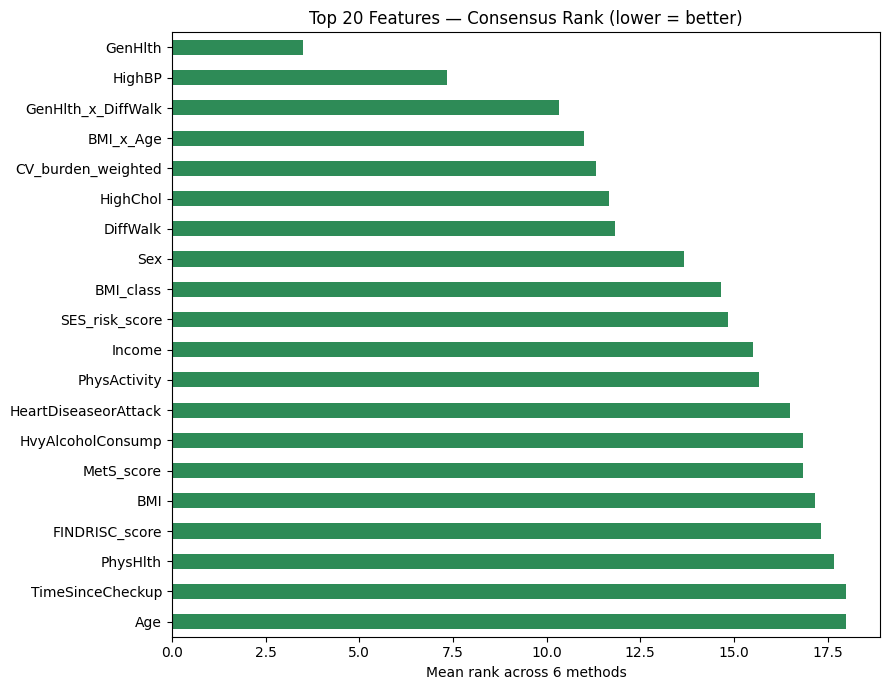

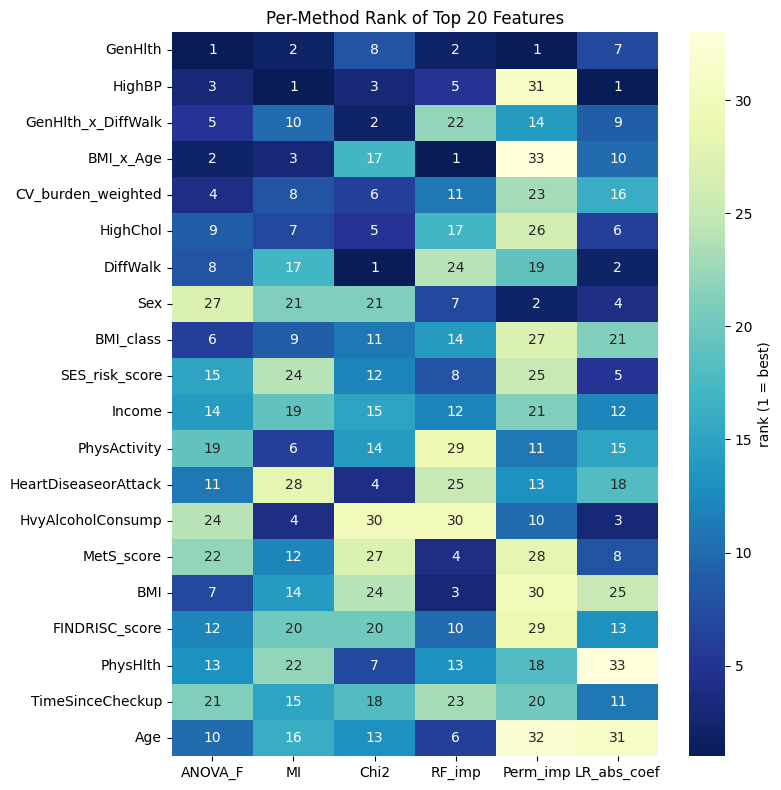

In [41]:
topk = 20
plt.figure(figsize=(9, 7))
fs_table.head(topk)["consensus_rank"][::-1].plot(
    kind="barh", color="seagreen"
)
plt.title(f"Top {topk} Features — Consensus Rank (lower = better)")
plt.xlabel("Mean rank across 6 methods")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
sns.heatmap(ranks.loc[fs_table.head(topk).index], annot=True, fmt=".0f",
            cmap="YlGnBu_r", cbar_kws={"label": "rank (1 = best)"})
plt.title(f"Per-Method Rank of Top {topk} Features")
plt.tight_layout()
plt.show()

### **FINAL FEATURE SET**

In [42]:
TOP_K = 20
selected_features = fs_table.head(TOP_K).index.tolist()
print(f"Selected {len(selected_features)} features:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f}")

X_train_final = X_train_fs[selected_features]
X_test_final  = X_test_fs[selected_features]
print("Final train:", X_train_final.shape, "| Final test:", X_test_final.shape)


Selected 20 features:
   1. GenHlth
   2. HighBP
   3. GenHlth_x_DiffWalk
   4. BMI_x_Age
   5. CV_burden_weighted
   6. HighChol
   7. DiffWalk
   8. Sex
   9. BMI_class
  10. SES_risk_score
  11. Income
  12. PhysActivity
  13. HeartDiseaseorAttack
  14. HvyAlcoholConsump
  15. MetS_score
  16. BMI
  17. FINDRISC_score
  18. PhysHlth
  19. TimeSinceCheckup
  20. Age
Final train: (200055, 20) | Final test: (50014, 20)


In [45]:
OUT_DIR  = "/content/drive/MyDrive/BRFSS2015_processed"
os.makedirs(OUT_DIR, exist_ok=True)

X_train_final.assign(Diabetes=y_train.values).to_csv(
    f"{OUT_DIR}/train.csv", index=False)
X_test_final.assign(Diabetes=y_test.values).to_csv(
    f"{OUT_DIR}/test.csv",  index=False)
fs_table.to_csv(f"{OUT_DIR}/feature_selection_ranking.csv")

print(f"\nArtifacts saved to: {OUT_DIR}")
print(f"  - diabetes_012_risk_factors_BRFSS2015.csv   (26 cols: 22 Kaggle + 4 extra)")
print(f"  - train.csv   (engineered + selected features)")
print(f"  - test.csv    (engineered + selected features)")
print(f"  - feature_selection_ranking.csv")
print("\nPipeline complete.")


Artifacts saved to: /content/drive/MyDrive/BRFSS2015_processed
  - diabetes_012_risk_factors_BRFSS2015.csv   (26 cols: 22 Kaggle + 4 extra)
  - train.csv   (engineered + selected features)
  - test.csv    (engineered + selected features)
  - feature_selection_ranking.csv

Pipeline complete.
